Задача: 
1) Примените метод k-means для данных "diabetes.csv". 

Постройте кластера для следующих комбинаций атрибутов:

    - показатель BMI, возраст Age
    
    - показатель BloodPressure, возраст Age.

Постройте визуализацию ваших результатов

2) Примените метод иерархической кластеризации с выводом дендрограммы для тех же комбинаций атрибутов

# Кластеризация данных `diabetes.csv`

В этой работе последовательно выполним исходное задание без изменения его формулировки:

1. построим кластеры методом **K-Means** для двух пар признаков;
2. визуализируем найденные группы и центры кластеров;
3. построим **дендрограммы иерархической кластеризации** для тех же пар признаков;
4. в конце сформулируем аналитический вывод по полученным результатам.

Все программные блоки снабжены комментариями на русском языке. Notebook подготовлен так, чтобы его можно было запускать в **Google Colab**.

### Необходимые библиотеки

Для работы используются `pandas`, `scikit-learn`, `matplotlib` и `scipy`. В стандартной среде Google Colab эти библиотеки уже доступны, поэтому дополнительная установка обычно не требуется.

In [1]:
# Импортируем библиотеку pandas для работы с таблицами.
import pandas as pd

# Импортируем KMeans для кластеризации методом k-средних.
from sklearn.cluster import KMeans

# Импортируем matplotlib для построения графиков.
import matplotlib.pyplot as plt

# Импортируем функции для иерархической кластеризации и построения дендрограмм.
from scipy.cluster.hierarchy import dendrogram, linkage

# Path используем для удобной проверки наличия файла.
from pathlib import Path


# Имя исходного файла из задания.
data_path = Path('diabetes.csv')

# Если notebook запущен в Google Colab и файла рядом нет,
# предлагаем пользователю загрузить diabetes.csv с компьютера.
if not data_path.exists():
    try:
        from google.colab import files

        print('Файл diabetes.csv не найден. Выберите его для загрузки в Google Colab.')
        uploaded = files.upload()

        # Проверяем, что пользователь действительно загрузил нужный файл.
        if 'diabetes.csv' not in uploaded:
            raise FileNotFoundError(
                'Не найден файл diabetes.csv. Загрузите файл с точным именем diabetes.csv.'
            )
    except ImportError:
        # Эта ветка сработает при локальном запуске вне Google Colab.
        raise FileNotFoundError(
            'Поместите diabetes.csv в ту же папку, где запускается notebook.'
        )

# Загружаем CSV-файл в DataFrame.
df = pd.read_csv(data_path)

# Удаляем строки с пропущенными значениями NaN, если они присутствуют.
# В исходном наборе diabetes.csv явных NaN может не быть,
# однако такая проверка делает код устойчивее.
df = df.dropna().copy()

# Показываем первые 10 строк, чтобы убедиться, что данные загрузились корректно.
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [2]:
# Проверяем размер таблицы.
print('Размер датасета:', df.shape)

# Проверяем, что нужные для задания признаки присутствуют в таблице.
required_columns = ['BMI', 'BloodPressure', 'Age']
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(f'В датасете отсутствуют столбцы: {missing_columns}')

# Выводим описательные статистики по признакам, которые будут использоваться в кластеризации.
# Это помогает аналитику понять диапазоны значений до запуска алгоритма.
display(df[required_columns].describe().round(2))

# Отдельно проверяем нулевые значения.
# Для BMI и BloodPressure ноль может быть техническим или некорректным значением.
# В рамках исходного задания мы НЕ исправляем эти строки,
# а наблюдаем, как они повлияют на результат кластеризации.
print('Количество BMI = 0:', int((df['BMI'] == 0).sum()))
print('Количество BloodPressure = 0:', int((df['BloodPressure'] == 0).sum()))
print('Количество Age = 0:', int((df['Age'] == 0).sum()))

Размер датасета: (768, 9)


,BMI,BloodPressure,Age
count,768.00,768.00,768.00
mean,31.99,69.11,33.24
std,7.88,19.36,11.76
min,0.00,0.00,21.00
25%,27.30,62.00,24.00
50%,32.00,72.00,29.00
75%,36.60,80.00,41.00
max,67.10,122.00,81.00


Количество BMI = 0: 11
Количество BloodPressure = 0: 35
Количество Age = 0: 0


## 1. K-Means

Сначала применим метод **K-Means** для двух комбинаций признаков:

- `BMI` и `Age`;
- `BloodPressure` и `Age`.

В исходной лабораторной работе используется `k = 2`, поэтому для каждой пары признаков будем строить два кластера.

Центры кластеров BMI + Age:
[[31.43492366 26.42748092]
 [33.19016393 47.87295082]]


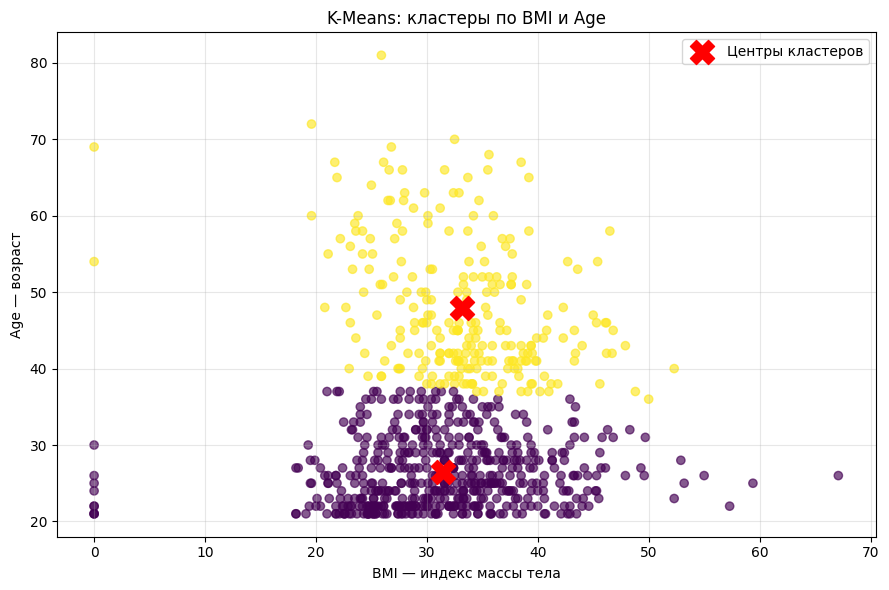

In [3]:
# ---------------------------------------------------------
# K-Means для признаков BMI и Age
# ---------------------------------------------------------

# Выбираем только два признака из условия задания.
# .values преобразует выбранные столбцы DataFrame в массив NumPy.
X1 = df[['BMI', 'Age']].values

# Создаём модель K-Means.
# n_clusters=2 — делим наблюдения на два кластера.
# n_init=10 — алгоритм несколько раз запускается с разными начальными центрами
#              и оставляет наиболее удачное решение.
# random_state=0 — фиксируем случайность, чтобы результат повторялся при каждом запуске.
kmeans1 = KMeans(n_clusters=2, n_init=10, random_state=0)

# Обучаем модель и одновременно получаем номер кластера для каждого наблюдения.
kmeans1.fit(X1)

# Выводим координаты центров кластеров.
# Первый столбец — координата по BMI, второй — по Age.
print('Центры кластеров BMI + Age:')
print(kmeans1.cluster_centers_)

# Создаём график.
plt.figure(figsize=(9, 6))

# Каждая точка — один объект из датасета.
# Цвет точки задаётся номером кластера, найденным K-Means.
plt.scatter(
    X1[:, 0],
    X1[:, 1],
    c=kmeans1.labels_,
    alpha=0.65
)

# Красными крестами отмечаем центры кластеров.
plt.scatter(
    kmeans1.cluster_centers_[:, 0],
    kmeans1.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Центры кластеров'
)

# Подписываем график на русском языке.
plt.xlabel('BMI — индекс массы тела')
plt.ylabel('Age — возраст')
plt.title('K-Means: кластеры по BMI и Age')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Создаём небольшую аналитическую таблицу,
# чтобы понять, чем найденные кластеры отличаются друг от друга.
cluster_bmi_age = df[['BMI', 'Age']].copy()
cluster_bmi_age['Cluster'] = kmeans1.labels_

# Рассчитываем количество объектов и средние значения признаков внутри каждого кластера.
profile_bmi_age = cluster_bmi_age.groupby('Cluster').agg(
    Количество=('Cluster', 'size'),
    Средний_BMI=('BMI', 'mean'),
    Средний_возраст=('Age', 'mean')
).round(2)

print('Профиль кластеров BMI + Age:')
display(profile_bmi_age)

Профиль кластеров BMI + Age:


,Количество,Средний_BMI,Средний_возраст
Cluster,,,
0,524,31.43,26.43
1,244,33.19,47.87


Центры кластеров BloodPressure + Age:
[[72.58767123 33.3890411 ]
 [ 2.21052632 30.39473684]]


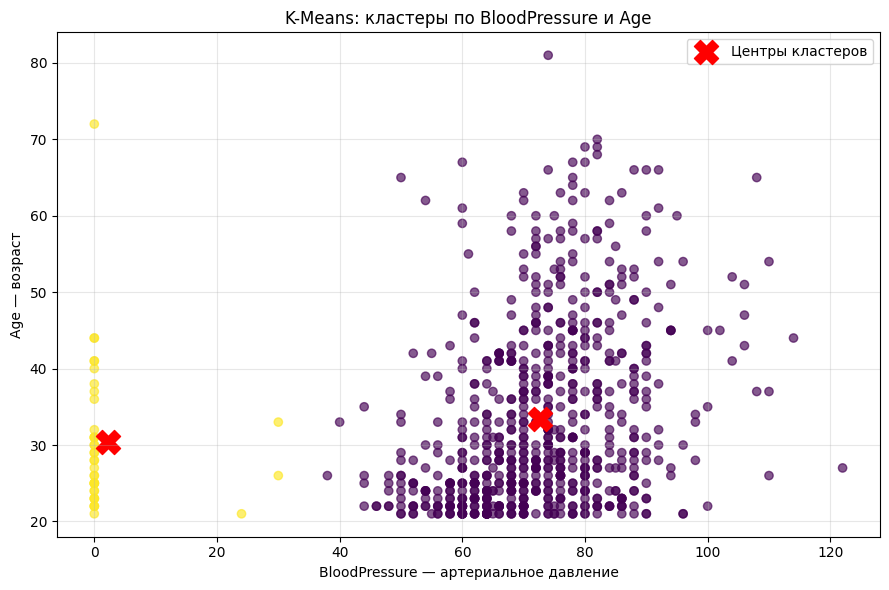

In [5]:
# ---------------------------------------------------------
# K-Means для признаков BloodPressure и Age
# ---------------------------------------------------------

# Выбираем вторую пару признаков из условия задания.
X2 = df[['BloodPressure', 'Age']].values

# Создаём и обучаем K-Means с двумя кластерами.
kmeans2 = KMeans(n_clusters=2, n_init=10, random_state=0)
kmeans2.fit(X2)

# Выводим координаты центров кластеров.
print('Центры кластеров BloodPressure + Age:')
print(kmeans2.cluster_centers_)

# Строим визуализацию найденных кластеров.
plt.figure(figsize=(9, 6))

plt.scatter(
    X2[:, 0],
    X2[:, 1],
    c=kmeans2.labels_,
    alpha=0.65
)

# Красными крестами показываем центры кластеров.
plt.scatter(
    kmeans2.cluster_centers_[:, 0],
    kmeans2.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Центры кластеров'
)

plt.xlabel('BloodPressure — артериальное давление')
plt.ylabel('Age — возраст')
plt.title('K-Means: кластеры по BloodPressure и Age')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Анализируем характеристики кластеров для BloodPressure + Age.
cluster_bp_age = df[['BloodPressure', 'Age']].copy()
cluster_bp_age['Cluster'] = kmeans2.labels_

profile_bp_age = cluster_bp_age.groupby('Cluster').agg(
    Количество=('Cluster', 'size'),
    Среднее_давление=('BloodPressure', 'mean'),
    Средний_возраст=('Age', 'mean')
).round(2)

print('Профиль кластеров BloodPressure + Age:')
display(profile_bp_age)

# Дополнительно проверяем строки с BloodPressure = 0.
# Это важный аналитический шаг: K-Means может выделять аномальные или технические значения
# в отдельную группу, хотя они не обязательно являются реальным содержательным сегментом.
zero_bp_count = int((df['BloodPressure'] == 0).sum())
print('Количество строк с BloodPressure = 0:', zero_bp_count)

display(
    df.loc[df['BloodPressure'] == 0, ['BloodPressure', 'Age', 'BMI', 'Outcome']].head(10)
)

Профиль кластеров BloodPressure + Age:


,Количество,Среднее_давление,Средний_возраст
Cluster,,,
0,730,72.59,33.39
1,38,2.21,30.39


Количество строк с BloodPressure = 0: 35


,BloodPressure,Age,BMI,Outcome
7,0,29,35.3,0
15,0,32,30.0,1
49,0,24,0.0,0
60,0,21,0.0,0
78,0,26,43.2,1
81,0,22,0.0,0
172,0,25,28.9,0
193,0,40,52.3,1
222,0,37,25.2,0
261,0,27,30.0,1


## 2. Иерархическая кластеризация

Теперь выполним иерархическую кластеризацию для тех же комбинаций признаков и выведем дендрограммы.

В исходной лабораторной работе рассматриваются два варианта связи между группами:

- `single` — расстояние между группами определяется по ближайшим объектам;
- `complete` — расстояние между группами определяется по наиболее удалённым объектам.

### Как читать дендрограмму

- нижние элементы соответствуют отдельным наблюдениям;
- при движении вверх похожие объекты и группы объединяются;
- высота объединения показывает расстояние между объединяемыми группами;
- большие вертикальные промежутки могут указывать на относительно самостоятельные группы объектов.

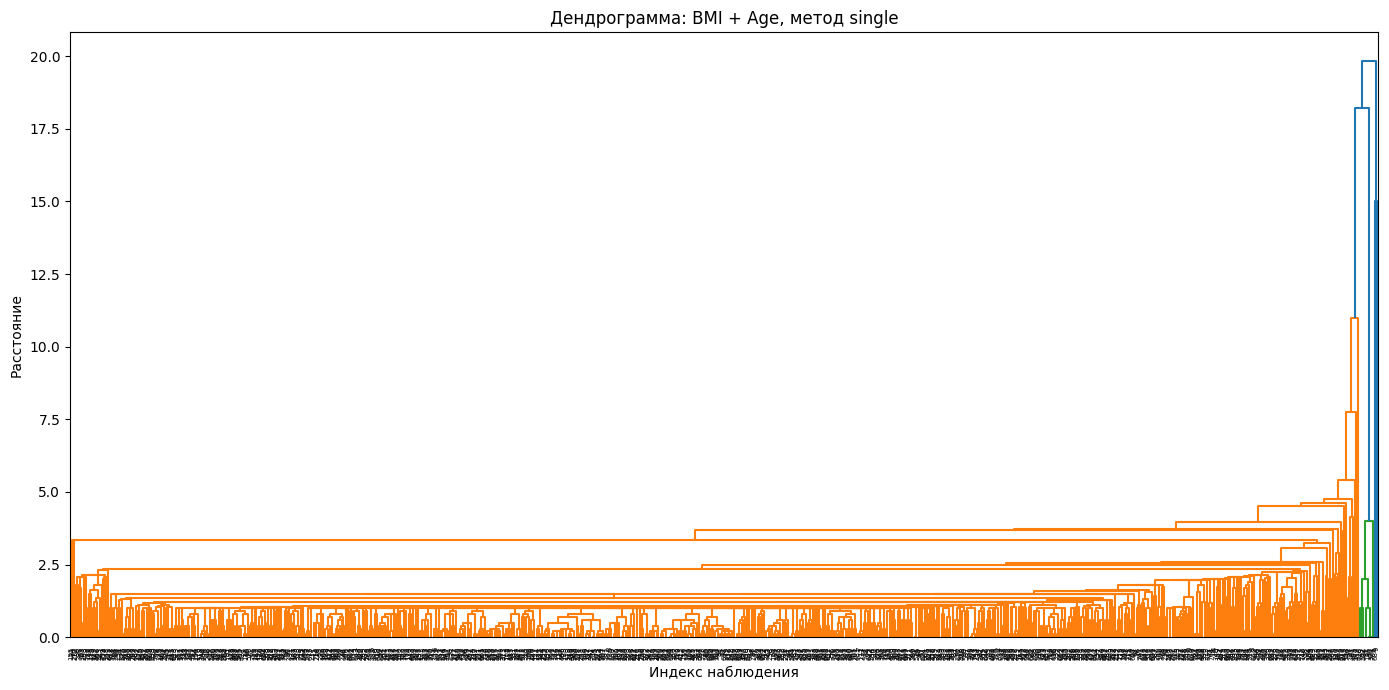

In [7]:
# ---------------------------------------------------------
# Иерархическая кластеризация: метод single
# BMI + Age
# ---------------------------------------------------------

# linkage строит иерархию последовательного объединения наблюдений.
# method='single' использует минимальное расстояние между объектами двух групп.
linked_bmi_age_single = linkage(df[['BMI', 'Age']], method='single')

plt.figure(figsize=(14, 7))

dendrogram(
    linked_bmi_age_single,
    orientation='top',
    labels=df.index.to_list(),
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_font_size=5
)

plt.xlabel('Индекс наблюдения')
plt.ylabel('Расстояние')
plt.title('Дендрограмма: BMI + Age, метод single')
plt.tight_layout()
plt.show()

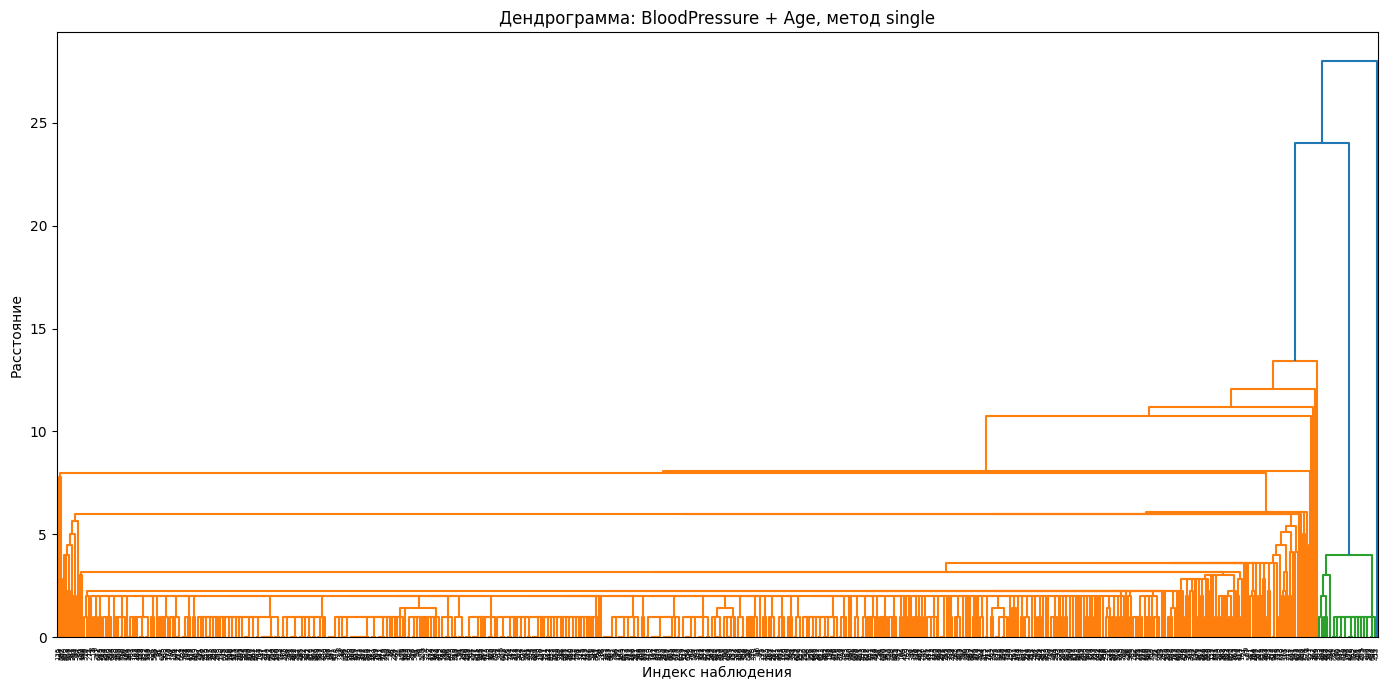

In [8]:
# ---------------------------------------------------------
# Иерархическая кластеризация: метод single
# BloodPressure + Age
# ---------------------------------------------------------

linked_bp_age_single = linkage(df[['BloodPressure', 'Age']], method='single')

plt.figure(figsize=(14, 7))

dendrogram(
    linked_bp_age_single,
    orientation='top',
    labels=df.index.to_list(),
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_font_size=5
)

plt.xlabel('Индекс наблюдения')
plt.ylabel('Расстояние')
plt.title('Дендрограмма: BloodPressure + Age, метод single')
plt.tight_layout()
plt.show()

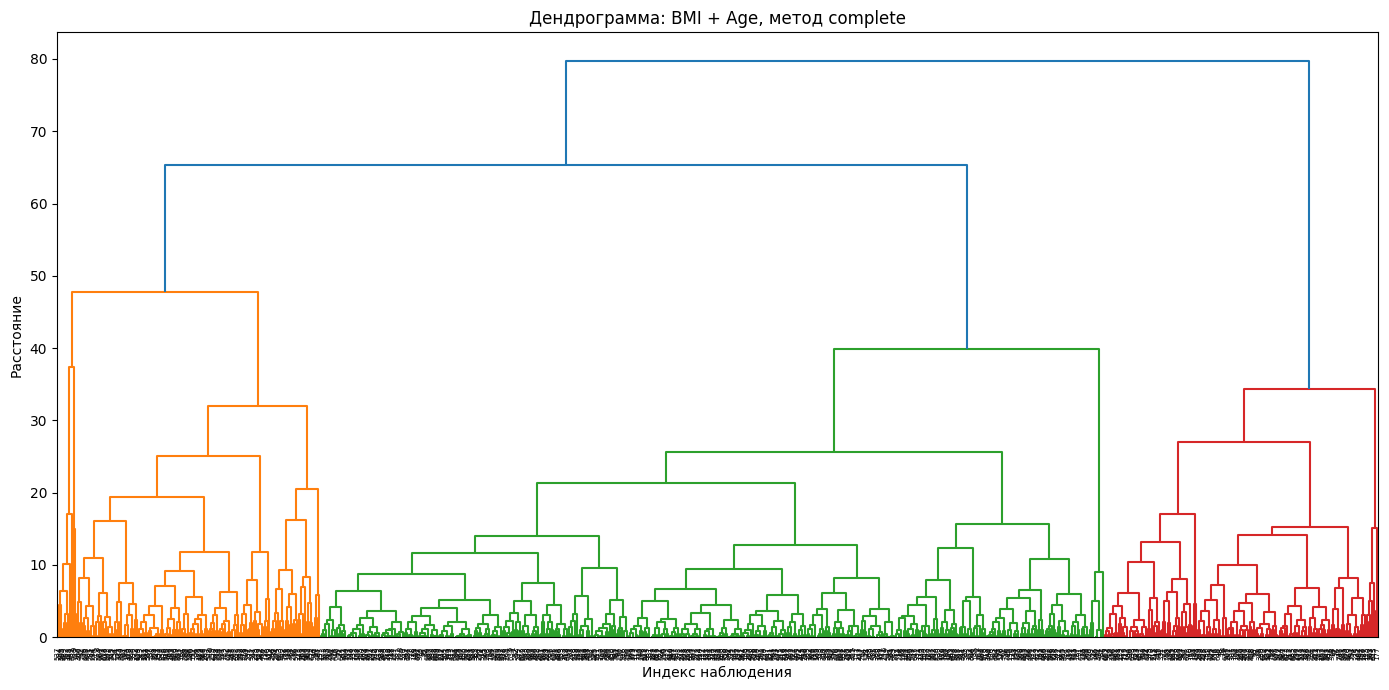

In [9]:
# ---------------------------------------------------------
# Иерархическая кластеризация: метод complete
# BMI + Age
# ---------------------------------------------------------

# method='complete' использует максимальное расстояние
# между объектами двух сравниваемых групп.
linked_bmi_age_complete = linkage(df[['BMI', 'Age']], method='complete')

plt.figure(figsize=(14, 7))

dendrogram(
    linked_bmi_age_complete,
    orientation='top',
    labels=df.index.to_list(),
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_font_size=5
)

plt.xlabel('Индекс наблюдения')
plt.ylabel('Расстояние')
plt.title('Дендрограмма: BMI + Age, метод complete')
plt.tight_layout()
plt.show()

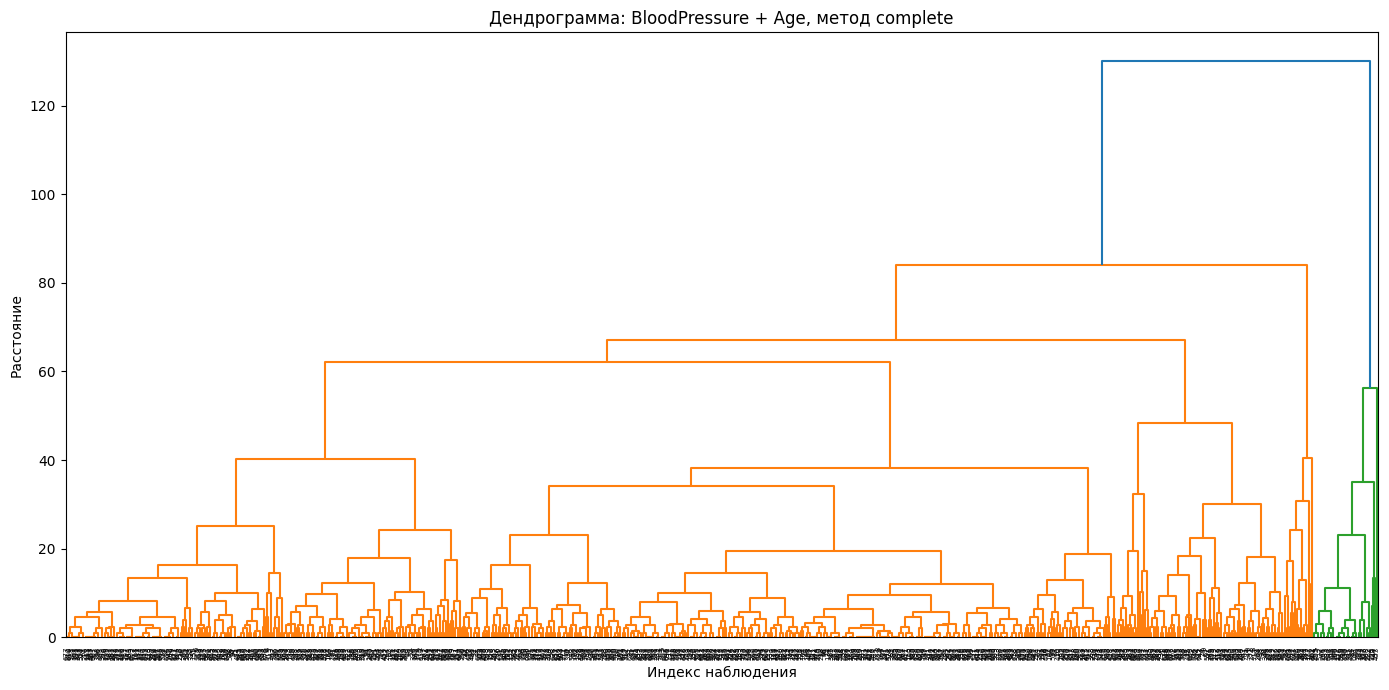

In [10]:
# ---------------------------------------------------------
# Иерархическая кластеризация: метод complete
# BloodPressure + Age
# ---------------------------------------------------------

linked_bp_age_complete = linkage(df[['BloodPressure', 'Age']], method='complete')

plt.figure(figsize=(14, 7))

dendrogram(
    linked_bp_age_complete,
    orientation='top',
    labels=df.index.to_list(),
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_font_size=5
)

plt.xlabel('Индекс наблюдения')
plt.ylabel('Расстояние')
plt.title('Дендрограмма: BloodPressure + Age, метод complete')
plt.tight_layout()
plt.show()

# Вывод по результатам анализа

В ходе практической работы к данным `diabetes.csv` были применены два метода кластерного анализа: **K-Means** и **иерархическая кластеризация**.

Для пары признаков **BMI и Age** метод K-Means разделил 768 наблюдений на два кластера. Первый кластер включает 524 наблюдения со средним возрастом около **26,43 года** и средним BMI около **31,43**. Второй кластер включает 244 наблюдения со средним возрастом около **47,87 года** и средним BMI около **33,19**. Следовательно, в этой комбинации признаков разделение в значительной степени связано с возрастом, тогда как различия по среднему BMI выражены слабее.

Для пары **BloodPressure и Age** получился особенно важный аналитический результат. Один кластер содержит 39 наблюдений со средним BloodPressure около **3,13**, а второй — 729 наблюдений со средним BloodPressure около **72,64**. Дополнительная проверка показала, что в исходном датасете присутствуют **35 строк со значением `BloodPressure = 0`**. Поэтому один из найденных кластеров в значительной мере отражает аномальные или технические значения исходных данных, а не обязательно отдельную содержательную группу пациентов.

Этот результат показывает важный принцип аналитики данных: **алгоритм кластеризации не знает предметного смысла значений**. Он группирует объекты по математическому сходству. Если в данных присутствуют аномалии или некорректные значения, алгоритм может выделить их в отдельный кластер. Поэтому после кластеризации необходимо обязательно анализировать характеристики найденных групп и качество исходных данных.

Иерархическая кластеризация для тех же пар признаков позволила увидеть последовательность объединения наблюдений в виде дендрограмм. Методы `single` и `complete` формируют различающуюся структуру дерева, так как используют разные правила расчёта расстояния между группами.

В результате оба подхода решают задачу поиска похожих объектов, но представляют результат по-разному. **K-Means** сразу присваивает каждому наблюдению номер одного из заданных кластеров и хорошо подходит для наглядного сравнения групп и их центров. **Иерархическая кластеризация** показывает структуру формирования групп на разных уровнях и позволяет визуально исследовать близость объектов через дендрограмму.

**Главный вывод:** получение номеров кластеров — это не конец анализа. Аналитику необходимо проверить качество исходных данных, изучить профили найденных групп и определить, имеют ли полученные кластеры содержательный смысл.